# Environmental Sound Classification Using Machine Learning

This project explores environmental sound classification using audio signal processing and machine learning. Audio recordings from the ESC-50 dataset are processed using Mel-Frequency Cepstral Coefficients (MFCCs) and classified using a k-Nearest Neighbours (k-NN) model.

The initial classification task focuses on distinguishing between two environmental sound classes: **dog** and **rain**.

The project covers audio exploration, feature extraction, dataset preparation, feature scaling, model selection, and evaluation on unseen test data.

## 1. Import Libraries

The project uses Python libraries for audio processing, numerical operations, data handling, visualisation, and machine learning.

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Audio Exploration

Before building the classifier, a single audio recording is explored to understand how digital audio can be represented and transformed into features suitable for machine learning.

This section examines the waveform, Short-Time Fourier Transform (STFT), spectrogram, Mel spectrogram, and Mel-Frequency Cepstral Coefficients (MFCCs).

In [2]:

file_path = "Unknown.wav"
audio, sr = librosa.load(file_path)
print("Sample rate:", sr)
print("Audio shape:", audio.shape)

Sample rate: 22050
Audio shape: (518175,)


### Waveform

The waveform shows how the amplitude of the audio signal changes over time. The horizontal axis represents time, while the vertical axis represents signal amplitude.

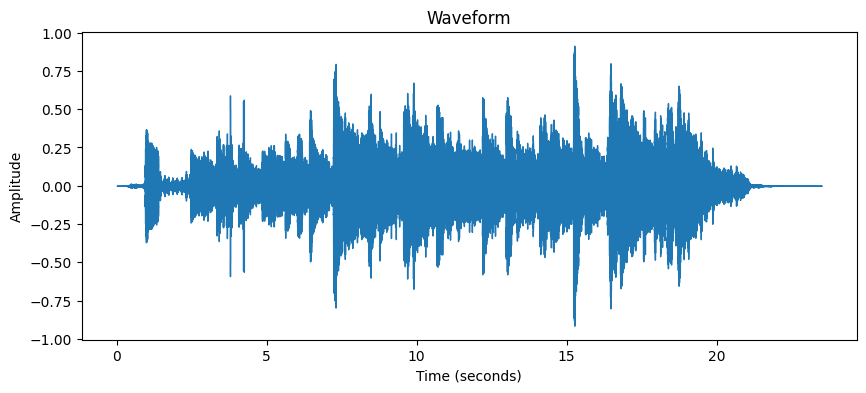

In [3]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


### Short-Time Fourier Transform (STFT)

The Short-Time Fourier Transform (STFT) divides the audio signal into short overlapping frames and analyses the frequency content within each frame. This allows changes in frequency over time to be represented.

The magnitude of the STFT is used to create a spectrogram, showing time on the horizontal axis, frequency on the vertical axis, and signal magnitude using colour intensity.

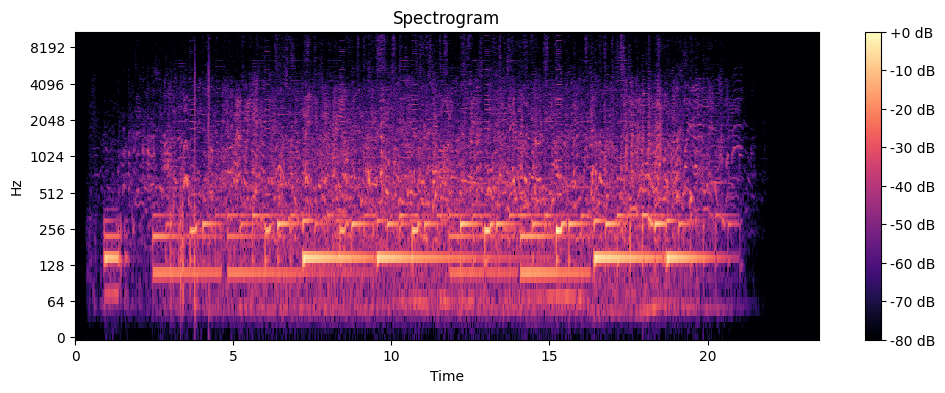

In [4]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.show()

### Mel Spectrogram

A Mel spectrogram represents the frequency content of an audio signal using the Mel scale, which approximates the way humans perceive differences in pitch.

The audio is converted into a Mel-scaled power spectrogram and then converted to decibels for visualisation. Compared with the STFT spectrogram, this representation places greater emphasis on perceptually relevant frequency information.

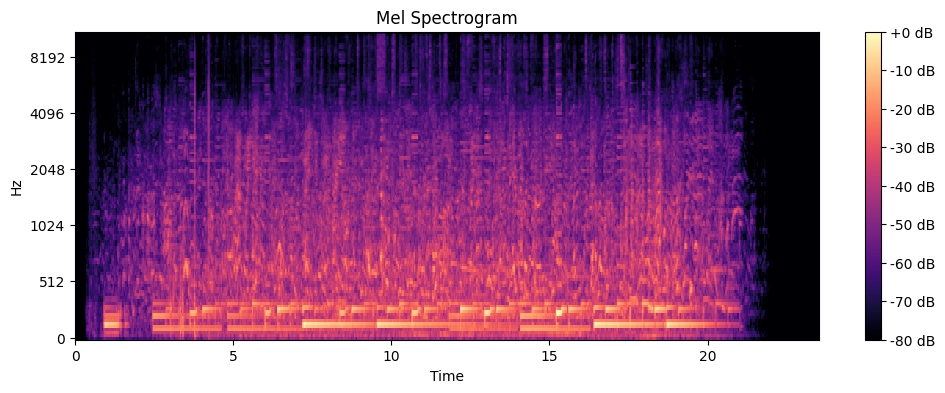

In [5]:
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)
mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)
plt.figure(figsize=(12, 4))
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.show()

### Mel-Frequency Cepstral Coefficients (MFCCs)

Mel-Frequency Cepstral Coefficients (MFCCs) provide a compact representation of the spectral characteristics of an audio signal. They are derived from a Mel-scaled representation of the frequency spectrum and are commonly used as features in audio and speech classification.

In this project, 13 MFCCs are extracted from the audio. Each coefficient describes different aspects of the spectral shape, producing a time-varying representation that can later be summarised into a fixed-size feature vector for machine learning.

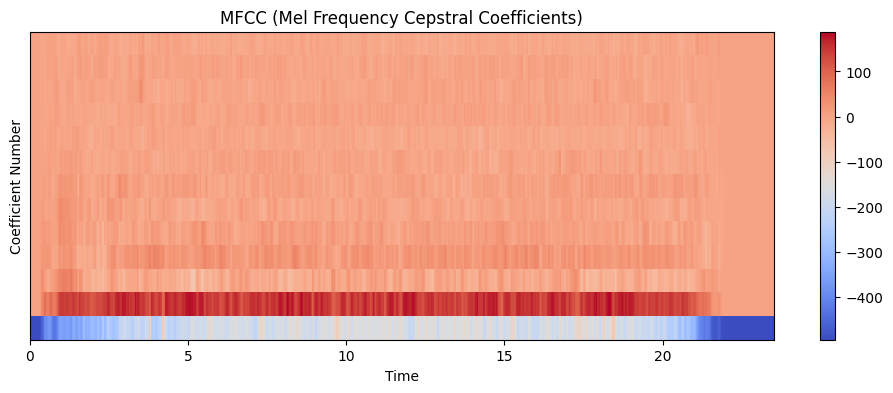

In [6]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)
plt.figure(figsize=(12,4))
librosa.display.specshow(
    mfcc,
    x_axis="time"
)
plt.colorbar()
plt.title("MFCC (Mel Frequency Cepstral Coefficients)")
plt.ylabel("Coefficient Number")
plt.show()

## 3. Dataset Preparation

The ESC-50 dataset contains 2,000 environmental audio recordings across 50 sound classes. Its metadata file provides information about each recording, including the filename and sound category.

For this initial binary classification experiment, recordings belonging to the **dog** and **rain** categories are selected from the dataset.

In [7]:
metadata_path = "ESC-50-master/meta/esc50.csv"
metadata = pd.read_csv(metadata_path)
metadata.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [8]:
selected_data = metadata[
    metadata["category"].isin(["dog", "rain"])
]
selected_data["category"].value_counts()

category
dog     40
rain    40
Name: count, dtype: int64

## 4. MFCC Feature Extraction

Each selected audio recording is loaded and represented using 13 Mel-Frequency Cepstral Coefficients (MFCCs).

Because MFCCs vary over time, the mean of each coefficient is calculated across all time frames. This converts each recording into a fixed-length feature vector containing 13 values.

These feature vectors form the input data (`X`), while the corresponding sound categories form the target labels (`Y`) used for machine learning.

In [9]:
X = []
Y = []

In [10]:
for index, row in selected_data.iterrows():
    audio_path = "ESC-50-master/audio/" + row["filename"]
    audio, sr = librosa.load(audio_path)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    X.append(mfcc_mean)
    Y.append(row["category"])

In [11]:
X = np.array(X)
Y = np.array(Y)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (80, 13)
Y shape: (80,)


## 5. Train, Validation and Test Split

The dataset is divided into separate training, validation and test sets. This allows the model to be trained, tuned and finally evaluated using unseen data.

First, 70% of the recordings are assigned to the training set. The remaining 30% are then divided equally between validation and test sets, producing a final 70/15/15 split.

Stratified sampling is used to preserve the balance between the dog and rain classes across each subset. A fixed random state is used to make the split reproducible.

In [12]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

In [13]:
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

In [14]:
print("Training:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Testing:", X_test.shape, Y_test.shape)

Training: (56, 13) (56,)
Validation: (12, 13) (12,)
Testing: (12, 13) (12,)


In [15]:
print("Training labels:", np.unique(Y_train, return_counts=True))
print("Validation labels:", np.unique(Y_val, return_counts=True))
print("Testing labels:", np.unique(Y_test, return_counts=True))

Training labels: (array(['dog', 'rain'], dtype='<U4'), array([28, 28]))
Validation labels: (array(['dog', 'rain'], dtype='<U4'), array([6, 6]))
Testing labels: (array(['dog', 'rain'], dtype='<U4'), array([6, 6]))


## 6. k-Nearest Neighbours Classification

A k-Nearest Neighbours (k-NN) classifier is used as the first machine learning model. k-NN classifies a new sample based on the labels of the most similar samples in the training data.

Several values of `k` are evaluated using the validation set. This allows the model configuration to be selected without using the test set, keeping the test data unseen until the final evaluation.

In [16]:
k_values = [1, 3, 5, 7, 9]
validation_accuracies = []

In [17]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    Y_val_pred = knn.predict(X_val)
    accuracy = accuracy_score(Y_val, Y_val_pred)
    validation_accuracies.append(accuracy)
    

In [18]:
for k, accuracy in zip(k_values, validation_accuracies):
    print("k =", k, "accuracy =", accuracy)

k = 1 accuracy = 1.0
k = 3 accuracy = 1.0
k = 5 accuracy = 1.0
k = 7 accuracy = 1.0
k = 9 accuracy = 1.0


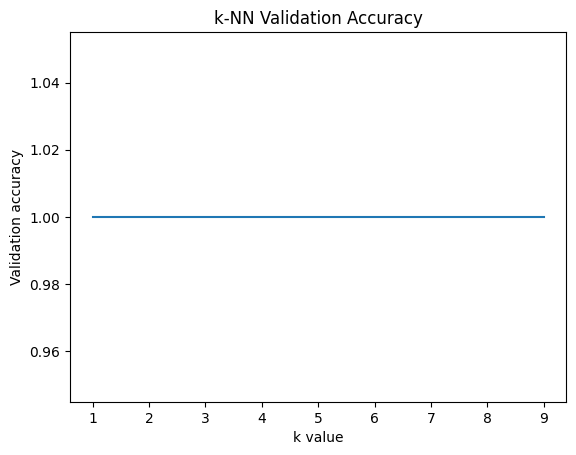

In [19]:
plt.plot(k_values, validation_accuracies)
plt.xlabel("k value")
plt.ylabel("Validation accuracy")
plt.title("k-NN Validation Accuracy")
plt.show()

### Feature Scaling

Because k-NN classifies samples using distances between feature vectors, differences in feature scale can influence the model. StandardScaler was therefore fitted using only the training data and then applied to the training and validation sets.

The k-NN models were evaluated again using the scaled MFCC features. All tested values of `k` achieved the same validation accuracy. Since validation performance did not distinguish between them, `k=3` was retained as a simple small odd value while avoiding reliance on a single nearest neighbour.

The test set remained unseen during model selection and is used only for the final evaluation.

In [20]:
scaler = StandardScaler()
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [21]:
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [22]:
scaled_validation_accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    Y_val_pred = knn.predict(X_val_scaled)
    accuracy = accuracy_score(Y_val, Y_val_pred)
    scaled_validation_accuracies.append(accuracy)

In [23]:
for k, accuracy in zip(k_values, scaled_validation_accuracies):
    print("k =", k, "scaled validation accuracy =", accuracy)

k = 1 scaled validation accuracy = 1.0
k = 3 scaled validation accuracy = 1.0
k = 5 scaled validation accuracy = 1.0
k = 7 scaled validation accuracy = 1.0
k = 9 scaled validation accuracy = 1.0


In [24]:
final_knn = KNeighborsClassifier(n_neighbors=3)
final_knn.fit(X_train_scaled, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## 7. Final Test Evaluation

After model selection and feature scaling, the final k-NN classifier was evaluated on the previously unseen test set.

The test set was not used during training, feature scaling, or hyperparameter evaluation. This provides an independent estimate of how well the classifier generalises to unseen recordings.

Performance is evaluated using overall accuracy, a confusion matrix, and class-specific precision, recall, and F1-score.

In [25]:
X_test_scaled = scaler.transform(X_test)
Y_test_pred = final_knn.predict(X_test_scaled)

In [26]:
test_accuracy = accuracy_score(Y_test, Y_test_pred)
print("Test accuracy:", test_accuracy)

Test accuracy: 0.9166666666666666


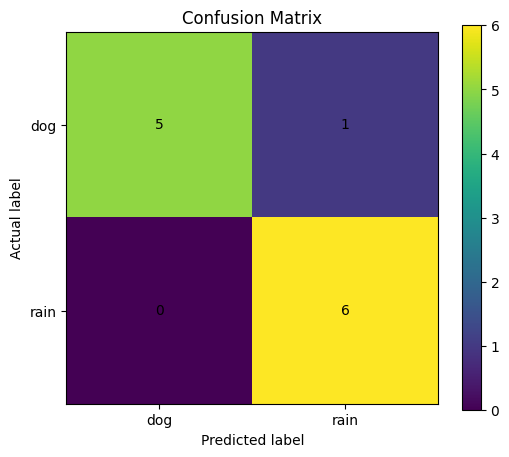

In [27]:
cm = confusion_matrix(Y_test, Y_test_pred, labels=["dog", "rain"])
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0, 1], ["dog", "rain"])
plt.yticks([0, 1], ["dog", "rain"])
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

In [28]:
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

         dog       1.00      0.83      0.91         6
        rain       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



## 8. Results and Conclusion

The final k-NN classifier achieved a test accuracy of 91.67%, correctly classifying 11 of the 12 previously unseen recordings.

The confusion matrix shows that all six rain recordings were classified correctly, while five of the six dog recordings were classified correctly. One dog recording was incorrectly classified as rain.

The classification report produced F1-scores of 0.91 for dog and 0.92 for rain. These results demonstrate that mean MFCC feature vectors can provide useful information for distinguishing between the two environmental sound classes in this small dataset.

However, the test set contains only 12 recordings, so the result should not be interpreted as evidence of performance on a larger or more diverse dataset. Future work could evaluate the approach using additional sound classes, more recordings, alternative classifiers, and more comprehensive evaluation methods.